In [54]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from matplotlib import pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import itertools

# Example: Q_MAX river flow
q_min = pd.read_csv("q_min.csv")

# Optional: clean column names
q_min.columns = q_min.columns.str.strip().str.lower()

def prepare_time_series(df, value_name='flow'):
    months = ["jan","feb","mar","apr","maj","jun","jul","avg","sep","okt","nov","dec"]
    existing_months = [m for m in months if m in df.columns]

    # Convert to numeric and fill missing
    df[existing_months] = df[existing_months].apply(pd.to_numeric, errors='coerce')
    df[existing_months] = df[existing_months].fillna(method='ffill').fillna(method='bfill')

    # Melt to long format
    ts = df.melt(id_vars='year', value_vars=existing_months, var_name='month', value_name=value_name)
    ts['date'] = pd.to_datetime(ts['year'].astype(str) + '-' + ts['month'], format='%Y-%b', errors='coerce')
    ts = ts.dropna(subset=['date'])
    ts = ts.set_index('date').sort_index()
    ts = ts.dropna(subset=[value_name])
    
    # Ensure non-negative
    ts[value_name] = ts[value_name].clip(lower=0)
    
    return ts


def prepare_ml_data(ts, window_size=12, split_date='2014-01-01'):
    
    ts = ts.copy()
    ts['flow'] = ts['flow'].clip(lower=0)

    # Seasonal encoding
    ts['sin_month'] = np.sin(2 * np.pi * ts.index.month / 12)
    ts['cos_month'] = np.cos(2 * np.pi * ts.index.month / 12)

    flows = ts['flow'].values
    sin_m = ts['sin_month'].values
    cos_m = ts['cos_month'].values
    dates = ts.index

    X, y, idx = [], [], []
    for i in range(window_size, len(flows)):
        lag_vals = flows[i-window_size:i]
        features = np.concatenate([lag_vals, [sin_m[i], cos_m[i]]])
        
        X.append(features)
        y.append(flows[i])
        idx.append(dates[i])

    X = np.array(X)
    y = np.array(y)
    idx = pd.to_datetime(idx)

    # Log transform
    y_log = np.log1p(y)

    # Train/test split
    split_date = pd.to_datetime(split_date)
    split_idx = np.where(idx < split_date)[0]
    split = split_idx[-1] + 1 if len(split_idx) > 0 else 0

    return {
        "X_train": X[:split],
        "y_train": y_log[:split],
        "X_test": X[split:],
        "y_test": y[split:],        # original scale
        "idx_test": idx[split:]
    }

def nse(y_true, y_pred):
    """Nash-Sutcliffe Efficiency"""
    denom = np.sum((y_true - np.mean(y_true))**2)
    if denom == 0:
        return 0
    return 1 - np.sum((y_true - y_pred)**2) / denom

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    nse = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    return rmse, mae, nse

In [55]:

def tune_xgb(X_train, y_train):

    param_grid = { 'n_estimators': [500, 800, 1000], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.7, 0.8, 1.0], 'colsample_bytree': [0.7, 0.8 , 1.0] }

    tscv = TimeSeriesSplit(n_splits=5)

    best_score = -np.inf
    best_model = None
    params_best = None

    for n_est, max_d, lr, sub, col in itertools.product(
        param_grid['n_estimators'],
        param_grid['max_depth'],
        param_grid['learning_rate'],
        param_grid['subsample'],
        param_grid['colsample_bytree']
    ):

        scores = []

        # ✅ CROSS-VALIDATION (key fix)
        for train_idx, val_idx in tscv.split(X_train):

            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            model = XGBRegressor(
                n_estimators=n_est,
                max_depth=max_d,
                learning_rate=lr,
                subsample=sub,
                colsample_bytree=col,
                objective='reg:squarederror',
                random_state=42,
                n_jobs=-1)

            model.fit(X_tr, y_tr, verbose=False)

            # 🔥 evaluate on VALIDATION, not train
            y_pred_log = model.predict(X_val)

            # convert from log-scale
            y_pred = np.expm1(y_pred_log)
            y_true = np.expm1(y_val)

            score = nse(y_true, y_pred)
            scores.append(score)

        avg_score = np.mean(scores)

        if avg_score > best_score:
            best_score = avg_score
            params_best = (n_est, max_d, lr, sub, col)

    print("\nBest XGB params (CV NSE):", best_score)
    print("Params:", params_best)

    # ✅ retrain on full training set
    best_model = XGBRegressor(n_estimators=params_best[0], max_depth=params_best[1], learning_rate=params_best[2], subsample=params_best[3], colsample_bytree=params_best[4], objective='reg:squarederror', random_state=42, n_jobs=-1)

    best_model.fit(X_train, y_train)
    return best_model


def test_xgb_with_config(model, data):
    
    # -----------------------------
    # 1. Prepare data
    # -----------------------------

    X_train = data["X_train"]
    y_train = data["y_train"]
    X_test  = data["X_test"]
    y_test  = data["y_test"]
    idx     = data["idx_test"]

    # -----------------------------
    # 2. Build XGBoost model
    # -----------------------------

    #model.fit(X_train, y_train)

    # -----------------------------
    # 3. Predict (log → original)
    # -----------------------------
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    # -----------------------------
    # 4. Enforce non-negative
    # -----------------------------
    y_pred = np.maximum(y_pred, 0)

    # -----------------------------
    # 5. Align lengths
    # -----------------------------
    min_len = min(len(y_test), len(y_pred))
    y_test = y_test[:min_len]
    y_pred = y_pred[:min_len]
    idx = idx[:min_len]

    # -----------------------------
    # 6. Metrics
    # -----------------------------
    rmse, mae, nse_val = compute_metrics(y_test, y_pred)

    print("\n==============================")
    print(f"XGBoost (Tuned) Performance")
    print("==============================")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"NSE : {nse_val:.4f}")

    # -----------------------------
    # 7. Plot (2014–2025)
    # -----------------------------
    plt.figure(figsize=(14,5))
    plt.plot(idx, y_test, label='Actual')
    plt.plot(idx, y_pred, label='XGB Tuned', marker='x')
    plt.title(f"XGBoost Tuned Prediction: (2014–2025)")
    plt.xlabel("Date")
    plt.ylabel("Flow")
    plt.legend()
    plt.grid(True)
    plt.show()

    return y_pred


Best XGB params (CV NSE): 0.49191996712415537
Params: (500, 3, 0.01, 0.8, 1.0)

XGBoost (Tuned) Performance
RMSE: 26.01
MAE : 18.70
NSE : 0.4437


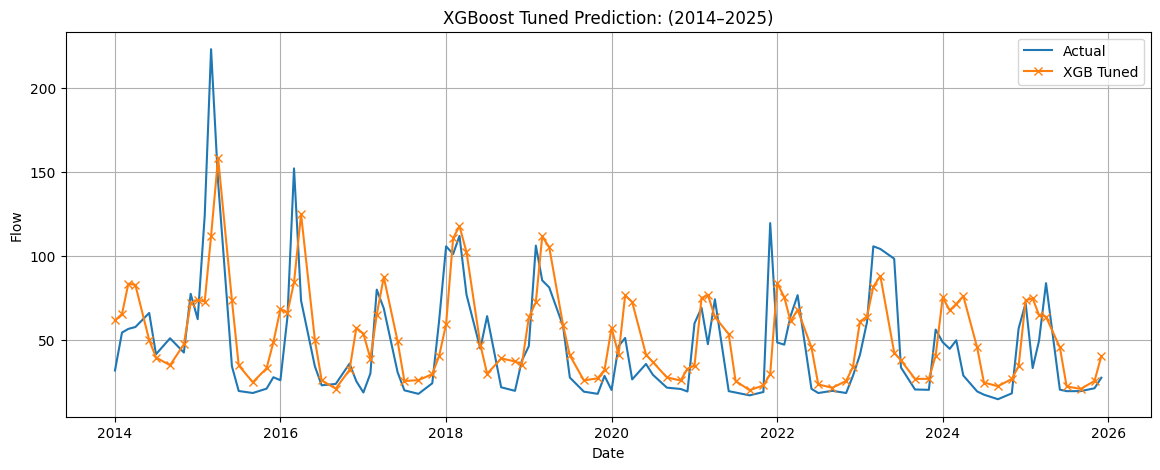

array([ 61.455765,  65.26941 ,  83.291084,  82.56409 ,  49.7641  ,
        39.3439  ,  34.771297,  47.21376 ,  71.6856  ,  73.739   ,
        72.69805 , 111.71694 , 158.38649 ,  73.41579 ,  34.6526  ,
        24.618439,  32.93742 ,  48.524666,  68.16797 ,  66.1045  ,
        84.17853 , 124.69838 ,  49.85643 ,  25.745289,  20.804941,
        32.015804,  57.08219 ,  53.570156,  38.71012 ,  64.8706  ,
        87.271454,  49.077118,  25.345085,  25.863773,  29.440258,
        40.196205,  59.14526 , 110.4275  , 117.67092 , 102.06391 ,
        47.078217,  29.63011 ,  38.796406,  37.012302,  35.02412 ,
        63.23885 ,  72.28394 , 111.44413 , 105.09038 ,  58.69346 ,
        40.568546,  25.727747,  26.950132,  31.957811,  56.99452 ,
        41.024292,  76.354866,  72.41773 ,  41.109936,  36.67546 ,
        27.498749,  25.663717,  32.664963,  34.514862,  74.762054,
        76.62745 ,  63.511585,  53.271435,  25.41785 ,  19.880634,
        22.716461,  29.48095 ,  83.5813  ,  75.35288 ,  60.896

In [56]:
# Example: Q_MAX river flow
q_min = pd.read_csv("q_min.csv")

# Optional: clean column names
q_min.columns = q_min.columns.str.strip().str.lower()

ts_qmin = prepare_time_series(q_min)
data = prepare_ml_data(ts_qmin)

## train-test split 
X_train = data["X_train"]
y_train = data["y_train"]

X_test  = data["X_test"]
y_test  = data["y_test"]
idx     = data["idx_test"]

model = tune_xgb(X_train, y_train)
test_xgb_with_config(model, data)
